In [370]:
# from google.colab import drive # remove the cell if not using colab
# drive.mount('/content/drive')

In [371]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
base_path = Path(".") # change to path folder with data 

# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

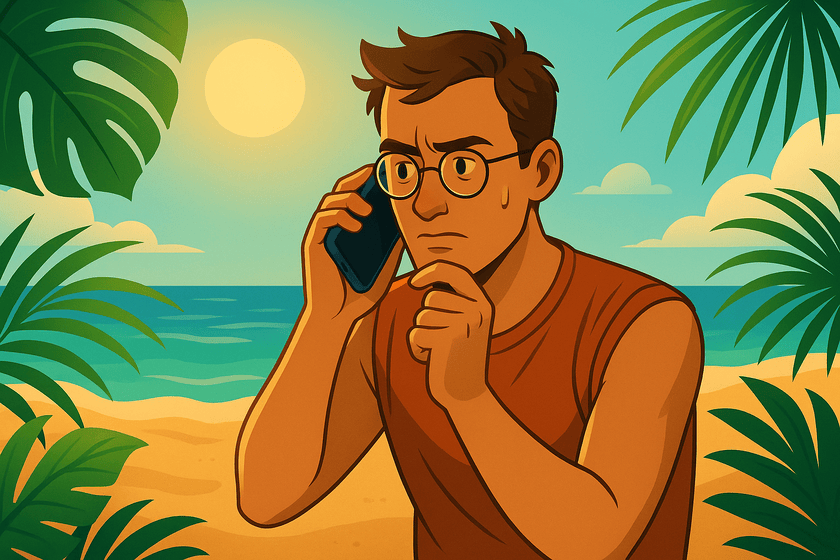

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [372]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [373]:
titanic_df.Survived.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [374]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

## ROZWIĄZANIE

In [375]:
print(f"Liczba obserwacji: {len(titanic_df)}")
print(f"Liczba kolumn: {titanic_df.shape[1]}")

Liczba obserwacji: 891
Liczba kolumn: 11


In [376]:
titanic_df.describe(include='all')

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,793.000000,204,889
unique,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,33.123938,NaN,NaN
std,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,51.578312,NaN,NaN
min,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.925000,NaN,NaN
50%,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.500000,NaN,NaN
75%,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN


In [377]:
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Jeśli planujemy analizę czy pasażer przeżył czy nie, możemy zastanowić się czy potrzebne nam są kolumny: `Name`, `Ticket`, `Fare`, `Cabin`.
Myślę że kolumny `Ticket` i `Fare` są w tym kontekście zbędne (dlatego w dalszej analizie nie zostaną uwzględnione), natomiast kolumna `Cabin` może zostać wykorzystana do wyodrębnienia pokładu (bardziej wartościową informacją jest numer pokładu niż konkretny numer kabiny).

In [378]:
titanic_df.drop(columns=['Fare', 'Ticket'], inplace=True)
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Cabin,Embarked
PassengerId,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,NaN,S


#### 1.2 Brakujące wartości

In [379]:
print("Liczba brakujących wartości w każdej kolumnie:")
titanic_df.isnull().sum()

Liczba brakujących wartości w każdej kolumnie:


Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Cabin       687
Embarked      2
dtype: int64

In [380]:
percent_missing = titanic_df.isnull().sum() / len(titanic_df) * 100
print("Liczba brakujących wartości w każdej kolumnie [%]:")
print(percent_missing)

Liczba brakujących wartości w każdej kolumnie [%]:
Survived     0.000000
Pclass       0.000000
Name         0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64


`Age` jest zmienną numeryczną więc możemy uzupełnić np. medianą.

`Cabin` jest zmienną kategorialną, ze względu na duży brak tych danych (~77%), najlepiej przypisać nową kategorię UNKNOWN (albo można zastanowić się nad jej usunięciem).

`Embarked` jest zmienną kategorialną, można braki uzupełnić korzystając z mody.

In [381]:
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('Unknown')
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

print("Liczba brakujących wartości w każdej kolumnie po uzupełnieniu braków:")
titanic_df.isnull().sum()

Liczba brakujących wartości w każdej kolumnie po uzupełnieniu braków:


Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Cabin       0
Embarked    0
dtype: int64

#### 1.3 Nowe kolumny
Na podstawie kolumny `Cabin` stworzymy nową zmienną `Deck`, która będzie zawierać informacje o pokładzie, na którym znajduje się kabina pasażera oraz zmienną `IsAlone`, która będzie wskazywać czy pasażer jest sam na statku (bez rodziny).

In [382]:
titanic_df['Deck'] = titanic_df['Cabin'].str[0]
titanic_df['Deck'] = titanic_df['Deck'].replace('U', 'Unknown')

titanic_df['IsAlone'] = np.where((titanic_df['SibSp'] + titanic_df['Parch']) > 0, 0, 1)
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Cabin,Embarked,Deck,IsAlone
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,Unknown,S,Unknown,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,C85,C,C,0
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,Unknown,S,Unknown,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,C123,S,C,0
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,Unknown,S,Unknown,1


#### 1.3 Typy danych

In [383]:
titanic_df.dtypes

Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Cabin        object
Embarked     object
Deck         object
IsAlone       int64
dtype: object

Zmienimy typ danych dla kilku kolumn - zmienimy w kilku przypadkach *object* na *category*, ponieważ jeśli mamy mało unikalnych wartości, ale występują one wiele razy, to dzięki tej zamianie zmniejszymy zużycie pamięci.

In [384]:
# Zmieniamy zmienne logiczne na bool
titanic_df["IsAlone"] = titanic_df["IsAlone"].astype(bool)

# Zmieniamy zmienne jakościowe na category (ponieważ mają ograniczoną liczbę unikalnych wartości)
titanic_df["Sex"] = titanic_df["Sex"].astype("category")
titanic_df["Pclass"] = titanic_df["Pclass"].astype("category")
titanic_df["Embarked"] = titanic_df["Embarked"].astype("category")
titanic_df["Deck"] = titanic_df["Deck"].astype("category")

#### 1.4 Rozkład zmiennych

- zmienne numeryczne

In [385]:
def hist_numeric(df: pd.DataFrame, column: str):
    mean_val = df[column].mean()
    median_val = df[column].median()
    skew_val = df[column].skew()
    sns.histplot(df[column], kde=True, bins=30)
    plt.axvline(mean_val, color='r', linestyle='dashed', linewidth=2, label=f'Średnia: {mean_val:.2f}')
    plt.axvline(median_val, color='g', linestyle='dashed', linewidth=2, label=f'Mediana: {median_val:.2f}')
    plt.title(f"Histogram: {column}\n(Skośność: {skew_val:.2f})")
    plt.xlabel(column)
    plt.ylabel('Częstość')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

In [386]:
def boxplot_numeric(df: pd.DataFrame, column: str):
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot: {column}")
    plt.xlabel(column)
    plt.grid(True, linestyle='--', alpha=0.7)

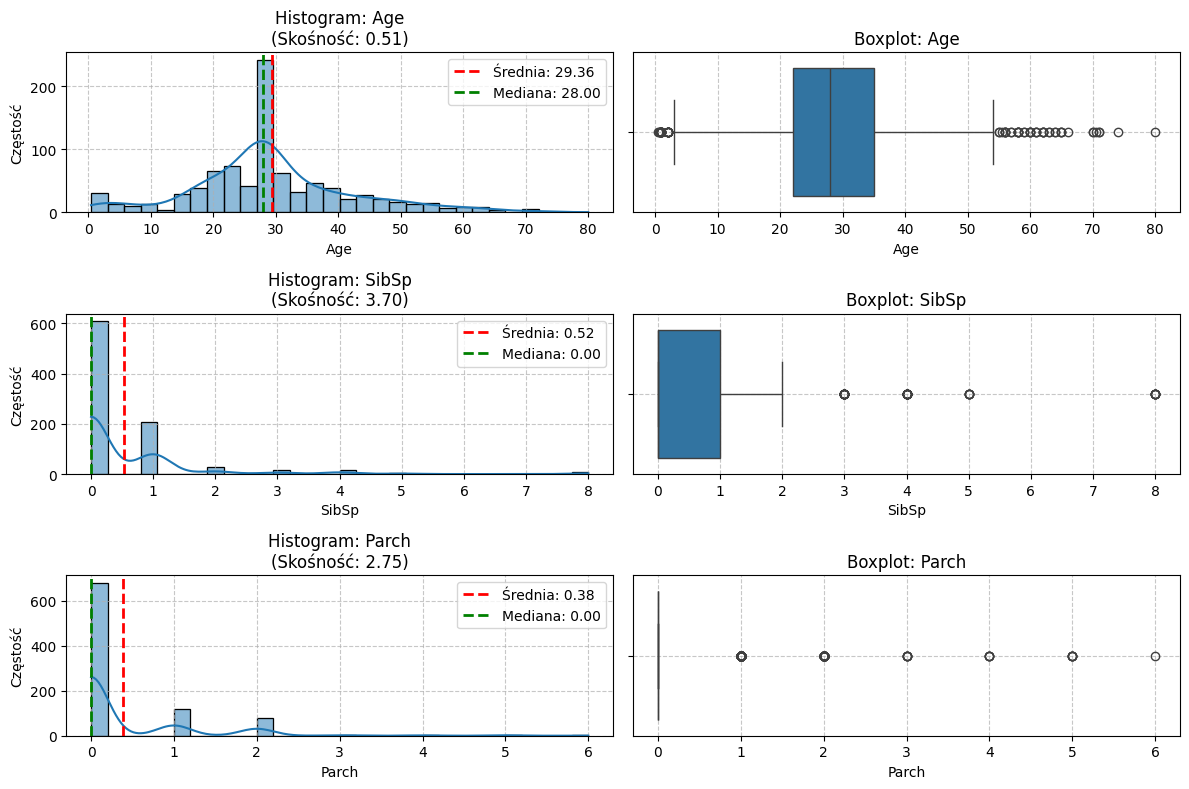

In [387]:
numeric_columns = ["Age", "SibSp", "Parch"]

plt.figure(figsize=(12, 8)) 

for idx, col in enumerate(numeric_columns):
    plt.subplot(len(numeric_columns), 2, 2 * idx + 1)
    hist_numeric(titanic_df, col) 
    
    plt.subplot(len(numeric_columns), 2, 2 * idx + 2)
    boxplot_numeric(titanic_df, col)

plt.tight_layout()
plt.show()

`Age` - umiarkowana (lekka) skośność, wartości średniej i mediany są bardzo do siebie zbliżone 

`SipSP` - silna skośność prawostronna (większość wyników jest mniejsza niż średnia - więc nie mamy rozkładu symetrycznego)

`Parch` - silna skośność prawostronna (większość wyników jest mniejsza niż średnia - więc nie mamy rozkładu symetrycznego)

Z tych trzech kolumn `Age` jest najbardziej zbliżona do rozkładu normalnego, natomiast `SibSp` oraz `Parch` to zmienne o ekstremalnej asymetrii prawostronnej.

Dodatkowo na boxplotach widzimy dużo wartości odstających (outlierów) dla każdej zmiennej.

- Zmienne kategorialne

In [388]:
def hist_categorical(df: pd.DataFrame, column: str):
    counts = df[column].value_counts()
    counts.plot(kind='bar', edgecolor='black')
    plt.title(f"Histogram: {column}")
    plt.xlabel(column)
    plt.ylabel('Liczba obserwacji')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

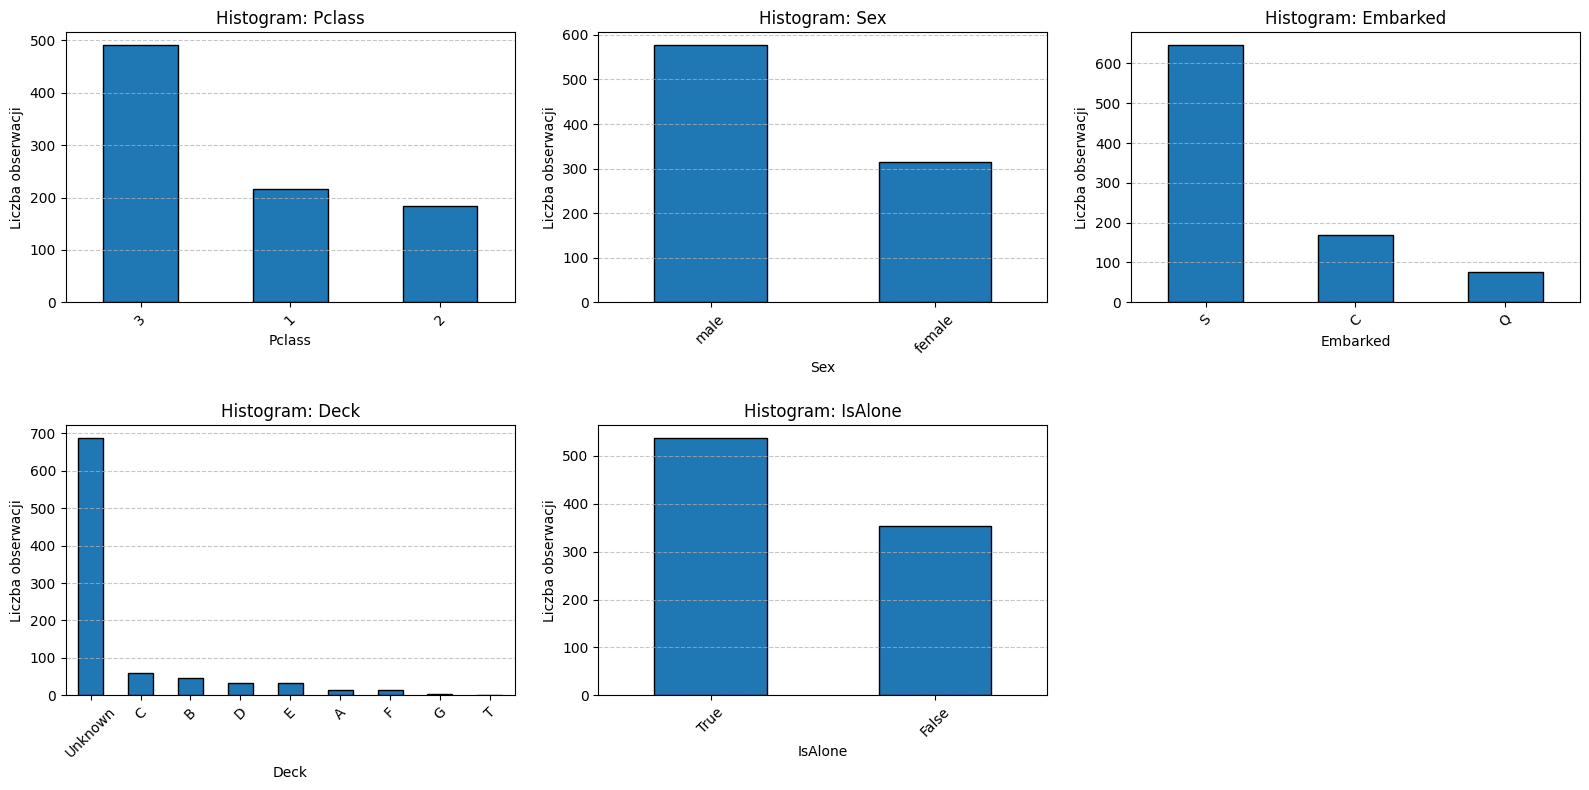

In [389]:
categorical_columns = ["Pclass", "Sex", "Embarked", "Deck", "IsAlone"]
plt.figure(figsize=(16, 8))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(2, 3, i)
    hist_categorical(titanic_df, col)
plt.tight_layout(w_pad=2.0, h_pad=2.0)
plt.show()

### 1.5 Zmienna predykowana

Zmienną, którą chcemy przewidywać, jest zmienna `Survived`:
- `0` – pasażer nie przeżył,
- `1` – pasażer przeżył.

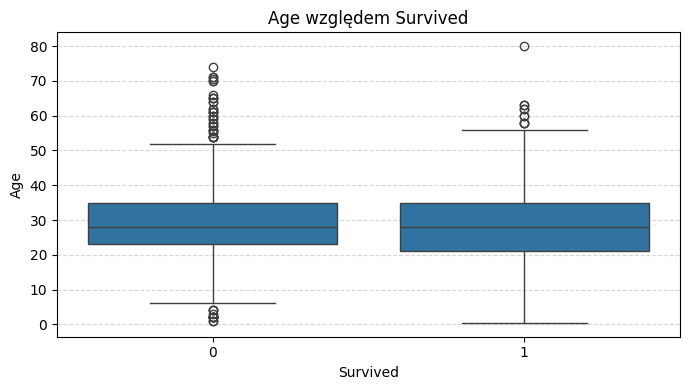

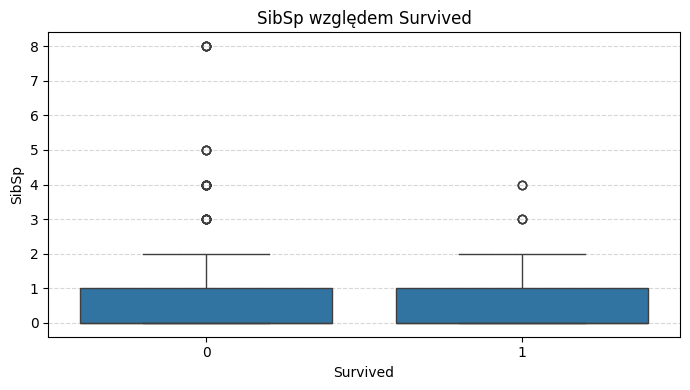

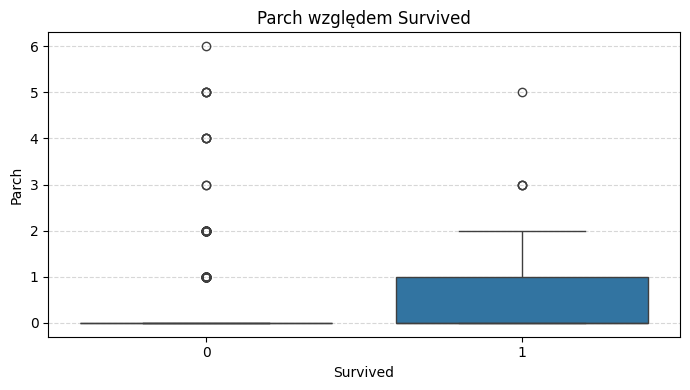

In [395]:
numeric_columns = ['Age', 'SibSp', 'Parch']

for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=titanic_df, x='Survived', y=column)
    plt.title(f'{column} względem Survived')
    plt.xlabel('Survived')
    plt.ylabel(column)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

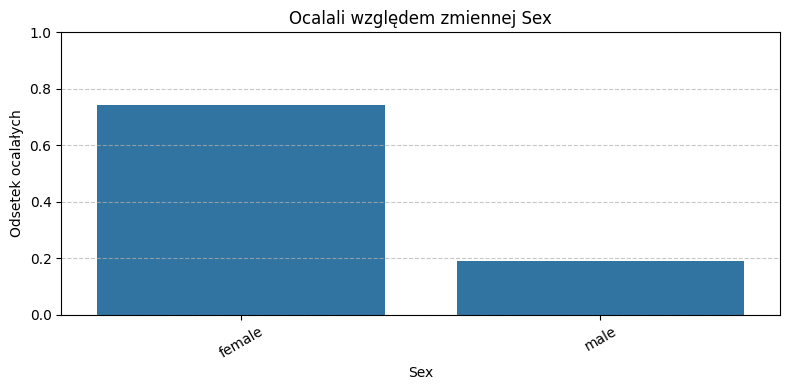

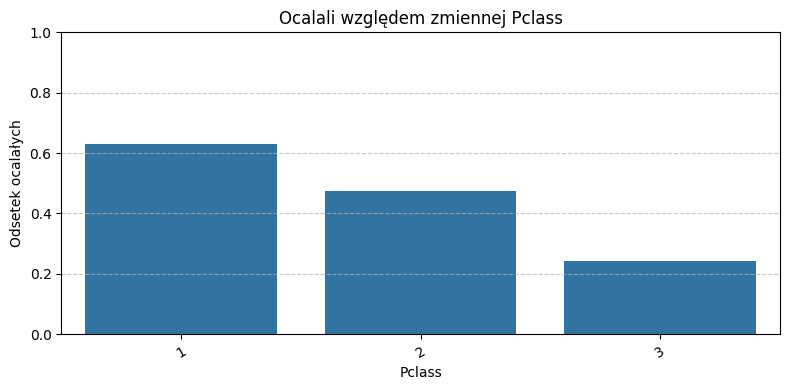

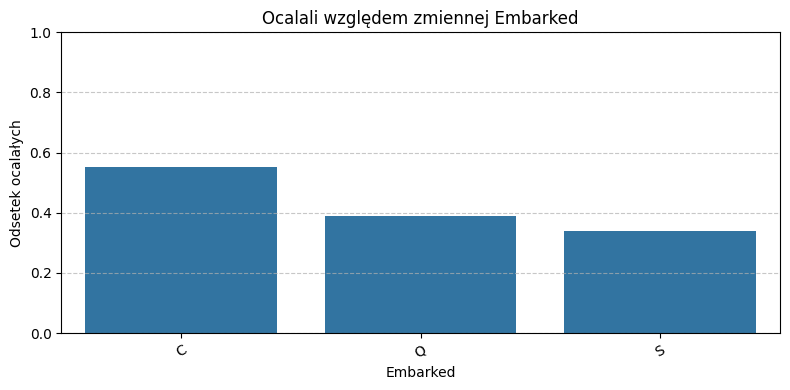

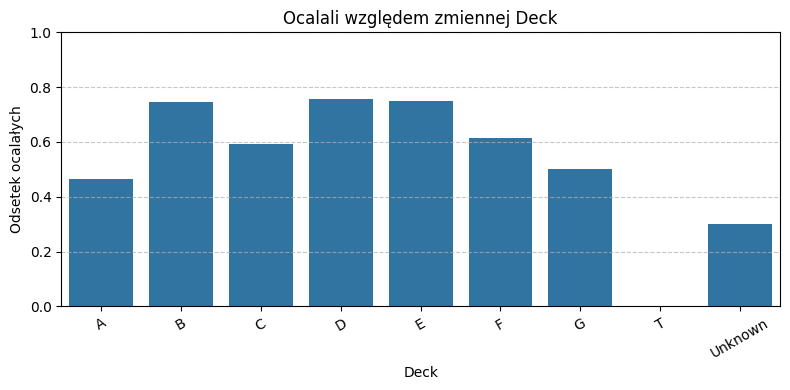

In [393]:
def survived_by_category(df, column):
    survival_rate = df.groupby(column, observed=False)['Survived'].mean().sort_values(ascending=False)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=survival_rate.index, y=survival_rate.values)
    plt.title(f'Ocalali względem zmiennej {column}')
    plt.xlabel(column)
    plt.ylabel('Odsetek ocalałych')
    plt.ylim(0, 1)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

for column in ['Sex', 'Pclass', 'Embarked', 'Deck']:
    survived_by_category(titanic_df, column)

#### 1.6 Zależności między zmiennymi

In [ ]:
def correlation_matrix(df: pd.DataFrame, size:tuple =(10, 8)):
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=size)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Macierz korelacji')
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

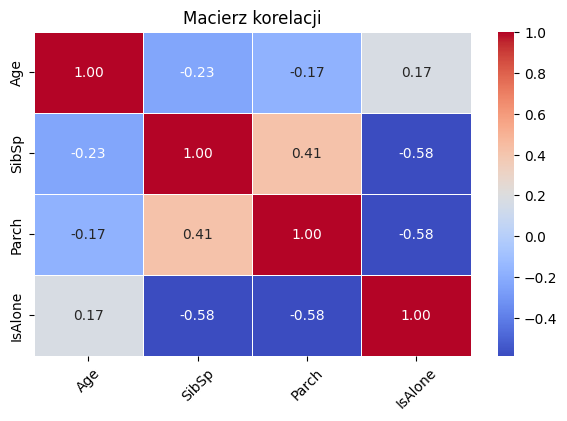

In [ ]:
correlation_matrix(titanic_df, (6,4))

#### 1.7 Kodowanie kolumn

In [ ]:
final_df = titanic_df.copy()

In [ ]:
# Kodowanie binarne (mamy tylko 2 opcje)
final_df["Sex"] = final_df["Sex"].map({"female": 0, "male": 1})

final_df["IsAlone"] = final_df["IsAlone"].astype(int)

# Kodowanie one-hot dla zmiennych nominalnych
final_df = pd.get_dummies(final_df, columns=["Embarked", "Deck"], dtype=int)

In [ ]:
titanic_df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Cabin,Embarked,Deck,IsAlone
PassengerId,,,,,,,,,,
1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,Unknown,S,Unknown,False
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,C85,C,C,False
3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,Unknown,S,Unknown,True
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,C123,S,C,False
5,3,"Allen, Mr. William Henry",male,35.0,0,0,Unknown,S,Unknown,True


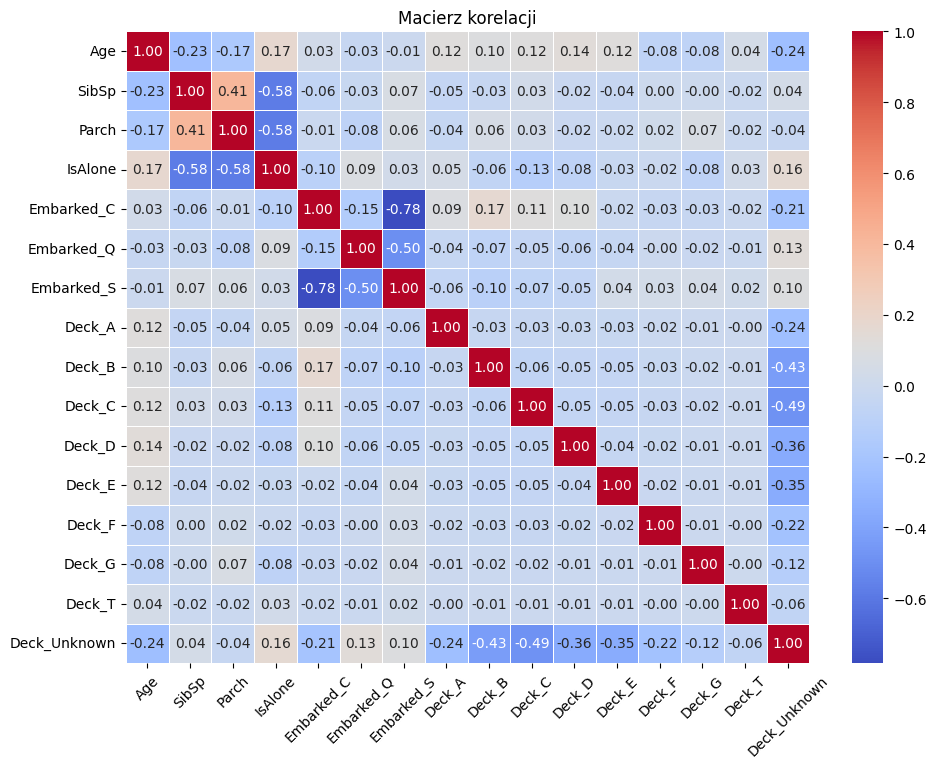

In [ ]:
correlation_matrix(final_df)